# Customer Purchase Prediction & Marketing Optimization Using Machine Learning

## Business Problem
Companies often spend large budgets on marketing campaigns without knowing which customers are likely to respond. This leads to wasted resources and low conversion rates.

## Objective
To build a machine learning model that predicts which customers are likely to make a purchase, enabling more targeted and efficient marketing strategies.

In [1]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load Dataset
df = pd.read_csv("marketing_campaign.csv", sep='\t')

# Display first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# Data Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# Dataset Shape
df.shape

(2240, 29)

In [5]:
# Statistical Summary
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [6]:
# Check Missing Values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
# Data Cleaning

# Fill missing values in Income using median
df['Income'] = df['Income'].fillna(df['Income'].median())

In [8]:
# Check if missing values are resolved
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [9]:
# Feature Engineering

# Create Age from Year_Birth
df['Age'] = 2026 - df['Year_Birth']

# Total Spending
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                           'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

# Total Purchases
df['Total_Purchases'] = df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)

In [10]:
# Check new features
df[['Age','Total_Spending','Total_Purchases']].describe()

,Age,Total_Spending,Total_Purchases
count,2240.000000,2240.000000,2240.000000
mean,57.194196,605.798214,12.537054
std,11.984069,602.249288,7.205741
min,30.000000,5.000000,0.000000
25%,49.000000,68.750000,6.000000
50%,56.000000,396.000000,12.000000
75%,67.000000,1045.500000,18.000000
max,133.000000,2525.000000,32.000000


In [11]:
# Target Variable
df['Target'] = df['Response']

In [12]:
# Remove unnecessary columns
X = df.drop(['Target', 'Response', 'ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'], axis=1)

# Target variable
y = df['Target']

In [13]:
# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [14]:
# Check dataset shape after encoding
X.shape

(2240, 36)

In [32]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
# Check shapes
X_train.shape, X_test.shape

((1792, 36), (448, 36))

In [17]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# Train Logistic Regression model (fixed)
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
# Make predictions
y_pred_lr = lr.predict(X_test)

In [34]:
# Evaluate model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8727678571428571


In [21]:
# Train Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
# Make predictions (Random Forest)
y_pred_rf = rf.predict(X_test)


In [23]:
# Evaluate model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8638392857142857


In [24]:
# Train XGBoost model
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
# Make predictions (XGBoost)
y_pred_xgb = xgb.predict(X_test)

In [26]:
# Evaluate model
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8727678571428571


In [27]:
# Model Comparison
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression: 0.8727678571428571
Random Forest: 0.8638392857142857
XGBoost: 0.8727678571428571


In [28]:
#Classification report
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       379
           1       0.67      0.35      0.46        69

    accuracy                           0.87       448
   macro avg       0.78      0.66      0.69       448
weighted avg       0.86      0.87      0.86       448

Random Forest Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       379
           1       0.62      0.29      0.40        69

    accuracy                           0.86       448
   macro avg       0.75      0.63      0.66       448
weighted avg       0.84      0.86      0.84       448

XGBoost Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       379
           1       0.66      0.36      0.47        69

    accuracy                           0.87       448
   macro avg       0.78      0.66      0.70       448
weigh

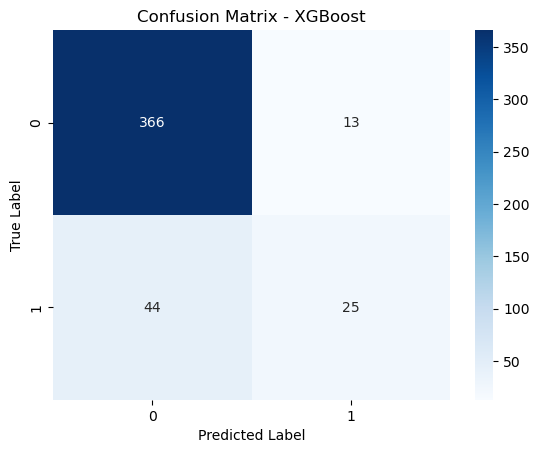

In [29]:
# Visualization - Confusion Matrix (XGBoost)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Display heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Model Interpretation

Logistic Regression and XGBoost achieved similar performance (87% accuracy), while Random Forest slightly underperformed (86%).

However, all models struggled to correctly identify customers who will respond to marketing campaigns, as shown by the low recall for class 1.

## Key Insights

The model shows strong performance in identifying non-responders but fails to capture a significant number of potential buyers, resulting in missed revenue opportunities for the business.

This results in high false negatives, meaning the company may miss customers who are actually likely to purchase, leading to lost revenue opportunities.

Improving recall for the positive class is critical for better marketing targeting.

## Limitations

- The dataset is imbalanced, which affects the model’s ability to detect buyers.
- Models tend to favor predicting non-buyers.
- Recall for class 1 remains relatively low across all models.

## Future Improvements

- Apply techniques such as SMOTE to handle class imbalance.
- Perform hyperparameter tuning for better model performance.
- Explore advanced models like LightGBM or CatBoost.
- Optimize for recall instead of accuracy.

## Conclusion

Logistic Regression and XGBoost delivered the best overall performance with similar accuracy (~87%), while Random Forest slightly underperformed.

Despite strong overall accuracy, all models struggled to identify potential buyers, as indicated by the low recall for the positive class. This suggests that the models are more effective at identifying non-responders than capturing customers likely to purchase.

From a business perspective, this limitation may lead to missed revenue opportunities, as potential buyers are not being effectively targeted.

Future improvements should focus on enhancing recall for the positive class through techniques such as handling class imbalance, hyperparameter tuning, and optimizing evaluation metrics aligned with business objectives.

Overall, this project demonstrates the importance of balancing model accuracy with business objectives when building predictive models for marketing optimization.